# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
import sys

sys.path.append("../utils")

import data_io

In [4]:
import colors
from embedding import plot_embedding, save_and_plot_feats
from mosaics import polygon_centroid, plot_multiple_mosaics
from dendrogram import ClusterDendrogram
from plot_cells import plot_cell_morphologies

# Data

In [5]:
config = data_io.get_data_config()
version = config.get("version", None)
skel_dir = config.get("skel_dir", None)
file_path = data_io.get_file_path(config)

In [6]:
assert os.path.isdir(skel_dir), skel_dir
assert os.path.isfile(file_path), file_path

In [7]:
df = pd.read_parquet(file_path)
df = df[(df.cellclass_final == 'BC')].copy()
df = df.drop(["polar_dens_1"], axis=1)  # Not needed
df = data_io.restore_numpy_arrays(df)

print(df.shape)

Restoring numpy arrays in column: hull_points
(41075, 399)


In [8]:
assert not df.columns.duplicated().any()

## Labels

In [9]:
plot_order = ['t1', 'GluMI', 't2', 't3a', 't3b', 't4', 't5o', 't5t', 't5i', 'XBC', 't7', 't6', 't8', 't9', 'RBC']

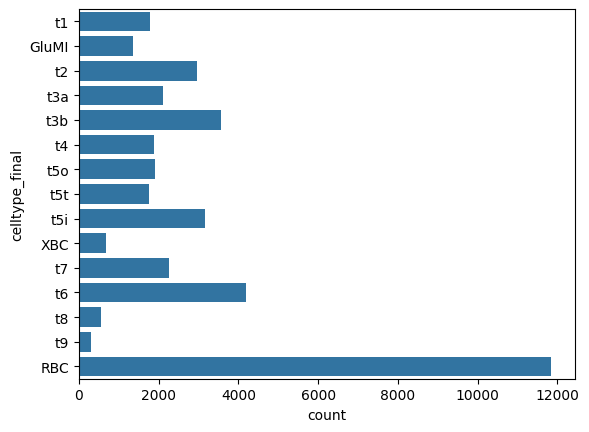

In [10]:
sns.countplot(df, y='celltype_final', order=plot_order);

## TSNE

In [11]:
emb_cols_norm = [c for c in df.columns if c.startswith('BCemb_norm')]
emb_cols_norm

['BCemb_norm-z-PC0',
 'BCemb_norm-z-PC1',
 'BCemb_norm-z-PC2',
 'BCemb_norm-z-PC3',
 'BCemb_norm-z-PC4',
 'BCemb_norm-z-PC5',
 'BCemb_norm-z-PC6',
 'BCemb_norm-z-PC7',
 'BCemb_norm-z-PC8',
 'BCemb_norm-z-PC9',
 'BCemb_norm-z-PC10',
 'BCemb_norm-z-PC11',
 'BCemb_norm-log_z_dens_sum',
 'BCemb_norm-log_hull_diameter',
 'BCemb_norm-log_hull_perimeter',
 'BCemb_norm-log_tips',
 'BCemb_norm-log_radius_mean',
 'BCemb_norm-log_radius_median',
 'BCemb_norm-log_radius_std',
 'BCemb_norm-log_radius_q5',
 'BCemb_norm-log_radius_q95']

In [12]:
emb_feats_norm = df[emb_cols_norm].values
emb_feats_norm.shape

(41075, 21)

In [13]:
import scanpy as sc

adata = sc.AnnData(df[emb_cols_norm].values)
sc.tl.tsne(adata, perplexity=30, use_rep='X', random_state=0)

In [14]:
df['tsne_d0'] = adata.obsm["X_tsne"][:, 0]
df['tsne_d1'] = adata.obsm["X_tsne"][:, 1]

## Select one per type

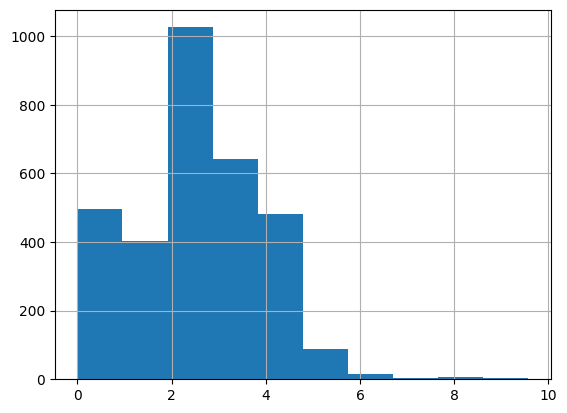

In [15]:
df.loc[df.post_has_soma == 1, 'soma_rad_um'].hist();

In [16]:
all_types_rows = []

for ct in plot_order:
    rows = df[(df['celltype_final'] == ct) & df.valid_celltype_final & df.post_has_soma & ((df.soma_rad_um > 4) & (df.soma_rad_um < 6))]
    
    if len(rows) == 0:
        rows = None
        print(celltype_final)

    if rows is None:
        row = None
    else:
        x = rows['tsne_d0']
        y = rows['tsne_d1']
        
        emb_ct = np.stack([x, y]).T
        
        ct_mean = np.mean(emb_ct, axis=0)
        ct_dists = np.sum((emb_ct - ct_mean) ** 2, axis=1) ** 0.5
        row = rows.iloc[np.argmin(ct_dists)]
        
    all_types_rows.append(row)
    
all_types_rows = pd.DataFrame(all_types_rows)
all_types_rows.head(2)

,ew,post_has_cal,post_has_axon,polar_dens_id_1,polar_dens_id_2,z_dens_id_1,row,link,nuc,status,...,ALLemb_norm-path_angle_q95,ALLemb_norm-log_radius_mean,ALLemb_norm-log_radius_median,ALLemb_norm-log_radius_std,ALLemb_norm-log_radius_q5,ALLemb_norm-log_radius_q95,hull_center_x,hull_center_y,tsne_d0,tsne_d1
720575940584946486,2,1,0,1,NaN,1,None,None,76849197462398756,ok,...,0.640988,0.516472,0.760312,0.174565,0.190656,0.222767,565.620178,781.363647,-46.216904,79.849213
720575940548323462,2,1,0,1,NaN,1,None,None,76217115715190786,ok,...,0.441916,-0.140306,-0.118440,0.164603,-0.831370,-0.016386,494.931610,930.254639,-65.901672,47.362316


# Figures

In [17]:
from style import set_rc_params

set_rc_params()

In [18]:
fig_dir = f'../figures/BC/v{version}'
os.makedirs(fig_dir, exist_ok=True)

## Colors

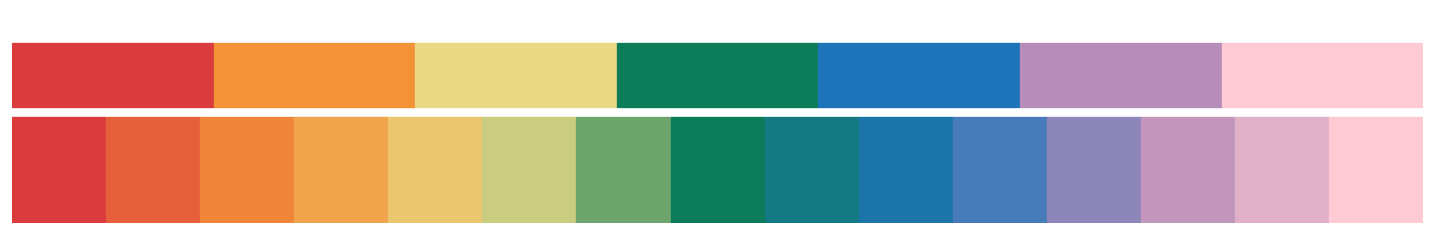

In [19]:
interpolated_colors = colors.interpolate_colors(n=len(plot_order))
ordered_colors = colors.reorder_colors_for_distinction(interpolated_colors, n_neighbors=4)

label2color = {leaf_name: ordered_colors[i] for i, leaf_name in enumerate(plot_order)}

In [20]:
label2color

{'t1': '#da3b3c',
 'GluMI': '#1b75ab',
 't2': '#ffcad4',
 't3a': '#8d86b8',
 't3b': '#f0a54c',
 't4': '#6ca46c',
 't5o': '#0c7c5a',
 't5t': '#e0b0c8',
 't5i': '#487bb9',
 'XBC': '#e5603a',
 't7': '#ecc56f',
 't6': '#137983',
 't8': '#c195bc',
 't9': '#ef8538',
 'RBC': '#cacc7f'}

## Dendrogram

In [21]:
cd = ClusterDendrogram(
    data=emb_feats_norm[df.valid_celltype_final],
    cluster_labels=df.loc[df.valid_celltype_final, "celltype_final"],
    feature_names=emb_cols_norm,
)
avg_features = cd.compute_cluster_averages(log_transform=False)
filtered_features, selected_features = cd.filter_features(verbose=False)
dist_matrix = cd.compute_distance_matrix(metric='euclidean')
Z = cd.hierarchical_cluster(method='average')

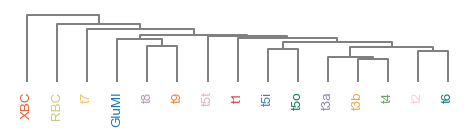

In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage

fig, ax = plt.subplots(figsize=(4, 1.2))
sns.despine(left=True, bottom=True, right=True, top=True)

# Plot dendrogram
dendro = dendrogram(
    cd.Z,
    labels=cd.clusters,
    ax=ax,
    leaf_font_size=8,
    color_threshold=0,
    above_threshold_color='gray',
    no_plot=False,
)

ax.tick_params("x", rotation=90)
xlabels = ax.get_xmajorticklabels()
xlabelnames = []
for label in xlabels:
    label.set_color(label2color[label.get_text()])

assert len(np.unique(xlabelnames)) == len(xlabelnames)


ax.set_yticks([])
plt.tight_layout()

fig.savefig(f'{fig_dir}/bc-dendrogram.svg')
fig.savefig(f'{fig_dir}/bc-dendrogram.png', dpi=600)

## Nearest neighbors

Removed 1 outlier for ct='t3a'
Removed 1 outlier for ct='t5i'
Removed 1 outlier for ct='t9'
Removed 5 outlier for ct='RBC'


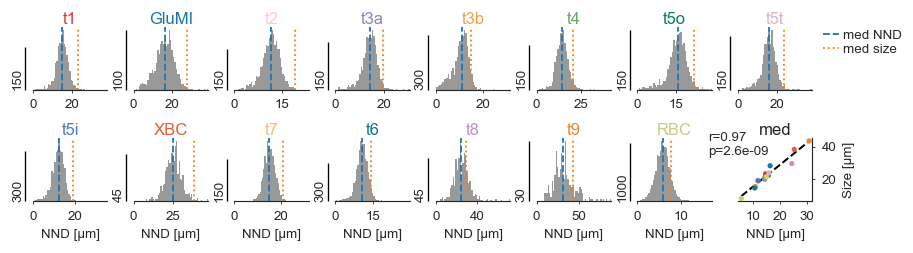

In [23]:
import matplotlib.ticker as ticker
from scipy.spatial import cKDTree
from scipy import stats


def add_scale_bar(ax, x_pos, x_pos_text, max_val, n_ticks=3):
    """Draw a vertical scale bar with a single label."""
    import math
    magnitude = 10 ** math.floor(math.log10(max_val)) if max_val > 0 else 1
    scale = round(max_val / magnitude * 0.5) * magnitude / 2
    if scale == 0:
        scale = magnitude / 2
    tick_values = [i * scale for i in range(n_ticks + 1) if i * scale <= max_val * 1.05]
    bar_height = tick_values[-1]
    ax.plot([x_pos, x_pos], [0, bar_height], color="black", solid_capstyle='butt', lw=0.8, clip_on=False)
    ax.text(x_pos_text, 0, f"{int(bar_height)}", ha="right", va="bottom", fontsize=8, rotation=90)


def plot_nnd_histograms(df, celltypes,
                        center_x_col="hull_center_x",
                        center_y_col="hull_center_y",
                        diameter_col="hull_diameter",
                        celltype_col="celltype_final"):

    df = df[df.valid_celltype_final].copy()
    nrows = min(2, len(celltypes) + 1)
    ncols = int(np.ceil((len(celltypes) + 1) / nrows))

    fig, axs = plt.subplots(nrows, ncols, figsize=(7.5, nrows * 1), squeeze=False)
    sns.despine(fig=fig)
    nnd_medians = {}
    dia_medians = {}

    for idx, ct in enumerate(celltypes):
        ax = axs[idx // ncols, idx % ncols]
        sub = df[df[celltype_col] == ct].dropna(subset=[center_x_col, center_y_col])

        # ── NND ──────────────────────────────────────────────────────────
        dists, _ = cKDTree(
            sub[[center_x_col, center_y_col]].values).query(
            sub[[center_x_col, center_y_col]].values, k=2)
        nnd = dists[:, 1]
        nnd_median = np.median(nnd)

        ood = nnd > 3 * nnd_median
        if np.any(ood):
            print(f"Removed {np.sum(ood)} outlier for {ct=}")
            nnd = nnd[~ood]

        # vertical histogram: values on x-axis
        sns.histplot(
            x=nnd, bins=51, ax=ax,
            color="gray", alpha=0.80,
            edgecolor="none", linewidth=0)
        ax.set(xlabel=None, ylabel=None)

        nnd_medians[ct] = np.median(nnd)
        ax.axvline(nnd_median, color="C0",
                   linewidth=1.1, linestyle="--", label="med NND")

        ax.set_xlim(0, np.nanmax(nnd))

        # ── Dendritic field size ─────────────────────────────────────────
        dia_median = np.median(sub[diameter_col].dropna())
        ax.axvline(dia_median, color="C1",
                   linewidth=1.1, linestyle=":", label="med size")

        dia_medians[ct] = dia_median

        ax.set_title(f"{ct}", color=label2color[ct], pad=1)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(2))
        ax.xaxis.set_major_locator(ticker.MaxNLocator(2))

        if idx == (ncols - 1):
            ax.legend(frameon=False, loc="upper left", handlelength=1.2, bbox_to_anchor=(1.1, 1))

        xlo, xhi = ax.get_xlim()
        xrange = xhi - xlo
        x_pos = xlo - 0.10 * xrange
        x_pos_text = xlo - 0.12 * xrange
            
        add_scale_bar(ax, x_pos=x_pos, x_pos_text=x_pos_text, max_val=ax.get_ylim()[1], n_ticks=3)
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)

    for ax in axs[-1, :]:
        ax.set_xlabel("NND [µm]")

    for idx in range(len(celltypes), nrows * ncols):
        axs[idx // ncols, idx % ncols].set_visible(False)

    ax = axs[-1, -1]
    ax.set_visible(True)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    
    df_scatter = pd.DataFrame({"NND [µm]": nnd_medians, "Size [µm]": dia_medians}).reset_index()
    vmax = np.maximum(df_scatter['Size [µm]'].max(), df_scatter['NND [µm]'].max())

    slope, intercept, r, p, _ = stats.linregress(df_scatter['NND [µm]'], df_scatter['Size [µm]'])
    x_line = np.linspace(df_scatter['NND [µm]'].min(), df_scatter['NND [µm]'].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, c='k', ls='--', zorder=-20)

    sns.scatterplot(df_scatter, x="NND [µm]", y="Size [µm]", clip_on=False,
                    hue='index', palette=label2color, legend=False, s=10, ec='none')
    #ax.set(label=None)
    ax.set_title('med', pad=1)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(True)

    fig.tight_layout(pad=0.4, h_pad=0.9, w_pad=0.4)

    ax.text(-0.4, 1.1, f"r={r:.2f}\np={p:.2g}", transform=ax.transAxes, va='top')

    return fig


fig = plot_nnd_histograms(df[df.valid_celltype_final], celltypes=plot_order)

fig.savefig(f'{fig_dir}/BC_NND.svg', dpi=600, bbox_inches='tight')
fig.savefig(f'{fig_dir}/BC_NND.png', dpi=600, bbox_inches='tight')
plt.show()

## TSNE

In [24]:
print((df['valid_celltype_final']).sum())
print((~df['valid_celltype_final']).sum())

40387
688


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/embedding.py:167: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


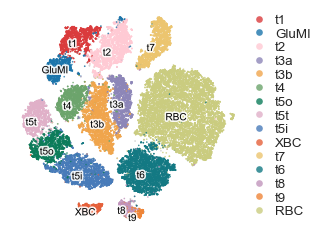

In [25]:
plot_embedding(
    df=df,
    label2color=label2color,
    fig_path_prefix=f"{fig_dir}/bc-tsne",
    celltype_col='celltype_final',
    plot_order=plot_order,
    is_labelled_col="valid_celltype_final",
    dot_size=1,
    edgecolor="none",
    rasterized=True,
    legend_markerscale=4,
    figsize=(2.5, 2.3)
)

## Feature maps

In [26]:
df.rename({"perc_z_050_3": "perc_z_050", "perc_z_025_3": "perc_z_025"}, axis=1, inplace=True)

In [27]:
example_feature_names = [
    'perc_z_025',
    'perc_z_050',

    'log_radius_median',
    'log_radius_q95',
    
    'log_tips',
    'log_hull_diameter',
]

example_features = df.loc[:, example_feature_names].values

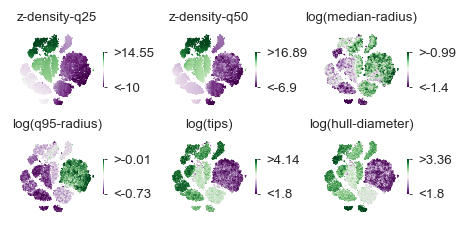

In [28]:
fig, axs = save_and_plot_feats(
    all_emb=df.loc[:, ['tsne_d0', 'tsne_d1']].values,
    all_feats=example_features,
    all_feat_names=example_feature_names, 
    ncols=3,
    clip=False,
    stride=1, 
    figsize_per_cell=(1.3, 1)
)

plt.tight_layout(h_pad=0.3)

fig.savefig(f'{fig_dir}/bc-tnse-features.svg', bbox_inches='tight')
fig.savefig(f'{fig_dir}/bc-tnse-features.png', dpi=600, bbox_inches='tight')

## Morph examples

0
6.9
Index([720575940584946486, 720575940548323462, 720575940556360242,
       720575940575641789, 720575940556299335, 720575940556607535,
       720575940557968476, 720575940560955472],
      dtype='int64')
[Info] scikit-sparse not found. Falling back to scipy.sparse.linalg.spsolve.


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:54: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


[pywarper.surface] Optional dependency 'scikit-sparse' (CHOLMOD bindings) not found. Falling back to SciPy's sparse linear solver, which is ≈5–10× slower for large problems.

For platform-specific instructions see the project README:
	https://github.com/berenslab/pywarper#installation


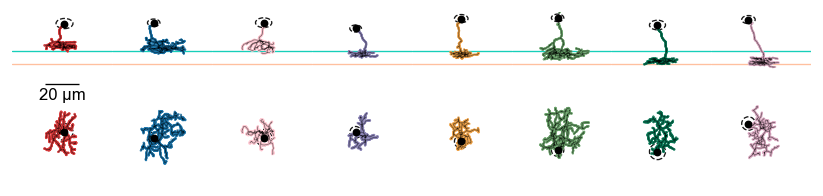

1
6.0375000000000005
Index([720575940578358294, 720575940552876357, 720575940573233696,
       720575940562402231, 720575940560802510, 720575940546965845,
       720575940559655189],
      dtype='int64')


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:54: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


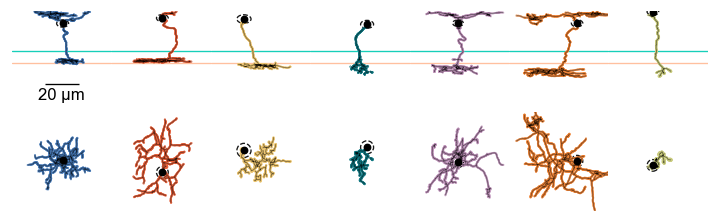

In [29]:
nrows = 2
ncols = int(np.ceil(len(all_types_rows) / nrows))

rad = (all_types_rows.hull_diameter.max() / 2) * 1.3

for i in range(nrows):
    print(i)
    rows = np.array_split(all_types_rows, nrows)[i]
    
    width = 6.9 * rows.shape[0] / ncols
    print(width)
    
    fig, axs = plt.subplots(
        2, len(rows), figsize=(width, 2.3), sharex='all', sharey='row', squeeze=False, height_ratios=(1.7, 4),
        subplot_kw=dict(xlabel=None, ylabel=None, xticks=[], yticks=[]), layout='tight')
    for ax in axs.flat:
        ax.axis('off')
    print(rows.index.astype(int))
    fig, _ = plot_cell_morphologies(
        rows=rows, rad=rad,
        skel_dir=skel_dir,
        size=20, fig=fig, axs=axs,
        color_list=[label2color[ct] for ct in rows['celltype_final'].values],
        show_on_tsne=False
    )

    fig.tight_layout(w_pad=0, h_pad=-0.5)

    if i == 0:
        shift_up = 0.1
        for ax in axs[-1, :]:
            pos = ax.get_position()
            ax.set_position([pos.x0, pos.y0 + shift_up, pos.width, pos.height])

    
    fig.savefig(f'{fig_dir}/celltype_final-example_set{i}({nrows}).svg', dpi=800, bbox_inches='tight')
    fig.savefig(f'{fig_dir}/celltype_final-example_set{i}({nrows}).png', dpi=800, bbox_inches='tight')
    
    plt.show()

## Coverage

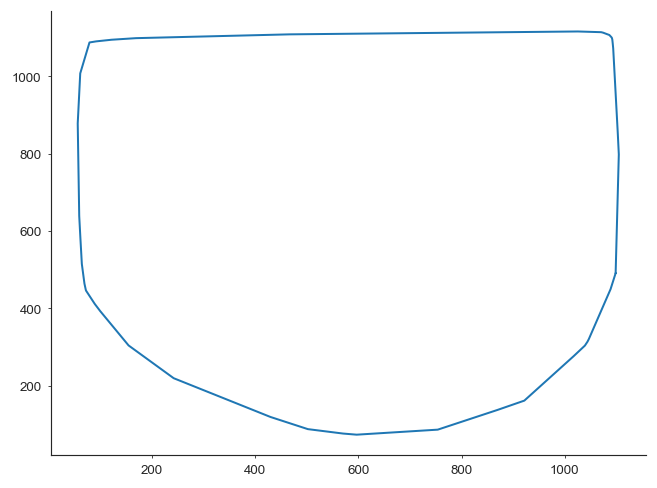

In [30]:
from scipy.spatial import ConvexHull

pts = np.vstack(df.hull_points)[:, :2]
hull = ConvexHull(pts)

# Get hull boundary points in order, closed
hull_pts = pts[np.append(hull.vertices, hull.vertices[0])]
plt.plot(*hull_pts.T)
plt.show()

celltype=np.str_('t1'): Found 1718 cells and 74 candidates.
celltype=np.str_('GluMI'): Found 1200 cells and 158 candidates.
celltype=np.str_('t2'): Found 2849 cells and 123 candidates.
celltype=np.str_('t3a'): Found 2022 cells and 94 candidates.
celltype=np.str_('t3b'): Found 3443 cells and 111 candidates.
celltype=np.str_('t4'): Found 1808 cells and 82 candidates.
celltype=np.str_('t5o'): Found 1785 cells and 126 candidates.
celltype=np.str_('t5t'): Found 1730 cells and 32 candidates.


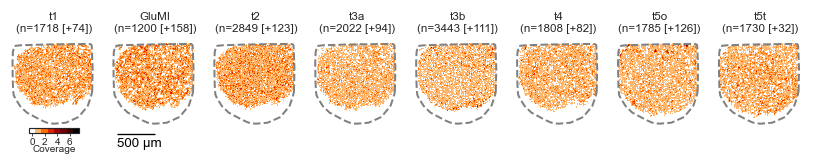

celltype=np.str_('t5i'): Found 3052 cells and 123 candidates.
celltype=np.str_('XBC'): Found 671 cells and 10 candidates.
celltype=np.str_('t7'): Found 2218 cells and 40 candidates.
celltype=np.str_('t6'): Found 4129 cells and 71 candidates.
celltype=np.str_('t8'): Found 491 cells and 78 candidates.
celltype=np.str_('t9'): Found 261 cells and 43 candidates.
celltype=np.str_('RBC'): Found 10094 cells and 1751 candidates.


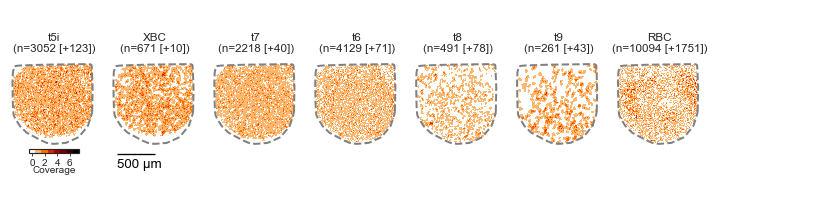

celltype=np.str_('t1'): Found 1718 cells and 74 candidates.
celltype=np.str_('GluMI'): Found 1200 cells and 158 candidates.
celltype=np.str_('t2'): Found 2849 cells and 123 candidates.
celltype=np.str_('t3a'): Found 2022 cells and 94 candidates.
celltype=np.str_('t3b'): Found 3443 cells and 111 candidates.
celltype=np.str_('t4'): Found 1808 cells and 82 candidates.
celltype=np.str_('t5o'): Found 1785 cells and 126 candidates.
celltype=np.str_('t5t'): Found 1730 cells and 32 candidates.


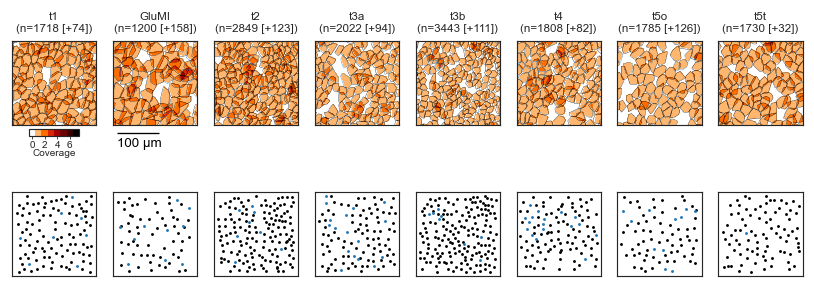

celltype=np.str_('t5i'): Found 3052 cells and 123 candidates.
celltype=np.str_('XBC'): Found 671 cells and 10 candidates.
celltype=np.str_('t7'): Found 2218 cells and 40 candidates.
celltype=np.str_('t6'): Found 4129 cells and 71 candidates.
celltype=np.str_('t8'): Found 491 cells and 78 candidates.
celltype=np.str_('t9'): Found 261 cells and 43 candidates.
celltype=np.str_('RBC'): Found 10094 cells and 1751 candidates.


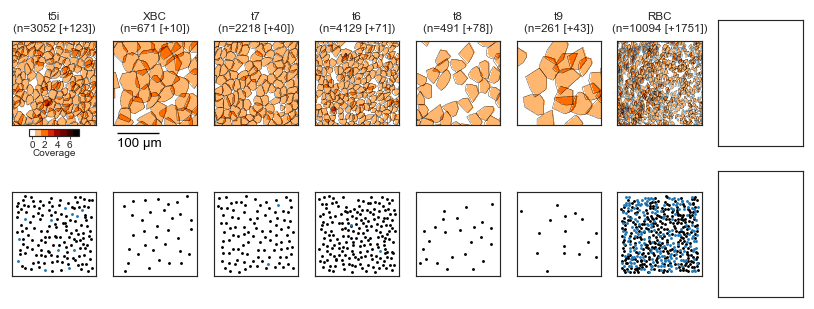

In [31]:
max_val = 7

for name, extent in {'wide': [50, 1150, 50, 1150], 'zoom': [200, 400, 600, 800], }.items(): # 'zoom2': [200, 300, 600, 700], 

    for i in range(nrows):
        celltypes_to_plot = np.array_split(plot_order, nrows)[i]

        plot_bodies = 'zoom' in name.lower()
        
        fig, axs = plt.subplots(ncols=ncols, nrows=2 if plot_bodies else 1,
                                figsize=(8.5, 3 if plot_bodies else 2),
                                sharex='row', sharey='row', squeeze=False)    
        if 'wide' in name.lower():
            sns.despine(top=True, right=True, left=True, bottom=True)
        else:
            sns.despine(top=False, right=False, left=False, bottom=False)
        
        ims, c_maxs = plot_multiple_mosaics(
            df=df[df.valid_celltype_final],
            celltype_col='celltype',
            candidate_col='celltype_final',
            candidate_color='C0',
            plot_candidate_coverage=True,
            celltypes=celltypes_to_plot,
            fig=fig,
            coverage_axs=axs[0, :],
            resolutions=[1000] * ncols,
            center_axs=axs[1, :] if plot_bodies else None,            
            title_axs=axs[0, :],
            sb_axs=[axs[0, 1]],
            center_x_col="hull_center_x",
            center_y_col="hull_center_y",
            marker_sizes=np.ones(ncols) * (0.1 if 'wide' in name.lower() else 3),
            max_val=max_val,
            extent=extent,
            plot_outlines='zoom' in name.lower(),
            outline_hull=hull_pts if 'wide' in name.lower() else None,
            cb=True,
            sb_size=500 if 'wide' in name.lower() else 100,
        )

        for celltype, ax in zip(celltypes_to_plot, axs[0, :]):
            df_ct = df[(df.celltype_final==celltype) & df.valid_celltype_final]
            n_cells = len(df_ct)
            n_cells_clf = sum(df_ct.celltype_final_decision == 'classifier')
            n_cells_label = n_cells - n_cells_clf
            if n_cells_clf > 0:
                ax.set_title(f"{celltype}\n(n={n_cells_label} [+{n_cells_clf}])", fontsize=7)
            else:
                ax.set_title(f"{celltype}\n(n={n_cells_label})", fontsize=7)
        
        fig.savefig(f'{fig_dir}/bc-{celltypes_to_plot}_set{i}({nrows})_{extent}.svg', dpi=600, bbox_inches='tight')
        fig.savefig(f'{fig_dir}/bc-{celltypes_to_plot}_set{i}({nrows})_{extent}.png', dpi=600, bbox_inches='tight')
        plt.show()

# Website

In [32]:
website_dir = f'../website/v{version}'
os.makedirs(website_dir, exist_ok=True)

In [33]:
website_cols = ['celltype_final', 'soma_x_um', 'soma_y_um', 'soma_z_um']

## Single examples

In [34]:
xy0 = np.array((48142, 36349)) * 16 / 1000
xy1 = np.array((42035, 31849)) * 16 / 1000
xy2 = np.array((37535, 37956)) * 16 / 1000
xy3 = np.array((43642, 42456)) * 16 / 1000

In [35]:
# Box center in um
box_center = (xy0 + xy1 + xy2 + xy3) / 4

website_rows = []
for celltype_final in plot_order:
    rows = df[
        (df.celltype_final == celltype_final)
        & df.valid_celltype_final
    ]
    
    if len(rows) == 0:
        website_rows.append(None)
        continue
    
    # Spatial distance to box center (medium priority)
    soma_xy = np.stack([rows.soma_annot_x_um, rows.soma_annot_y_um]).T
    spatial_dists = np.linalg.norm(soma_xy - box_center, axis=1)
    spatial_dists = np.clip(spatial_dists, 50, None)
    
    # tSNE distance to centroid (lowest priority, tiebreaker)
    emb_ct = np.stack([rows['tsne_d0'], rows['tsne_d1']]).T
    ct_mean = np.mean(emb_ct, axis=0)
    tsne_dists = np.linalg.norm(emb_ct - ct_mean, axis=1)
    
    # Strong flag (highest priority — invert so 0 = strong wins in argmin/lexsort)
    not_strong = (rows.celltype_final_decision != 'both_strong').values.astype(int)
    
    # lexsort sorts by LAST key as primary → put highest priority last
    order = np.lexsort((tsne_dists, spatial_dists, not_strong))
    row = rows.iloc[order[0]]
    
    website_rows.append(row)

df_website_single = pd.DataFrame(website_rows).loc[:, website_cols].copy()
df_website_single.sort_values('celltype_final', inplace=True)
df_website_single.head()

,celltype_final,soma_x_um,soma_y_um,soma_z_um
720575940577738025,GluMI,731.541,616.948,33.7622
720575940554483198,RBC,684.270,567.131,31.8555
720575940548532887,XBC,679.808,579.200,33.9897
720575940559412275,t1,648.259,588.360,35.0212
720575940558772794,t2,684.981,600.673,34.6418


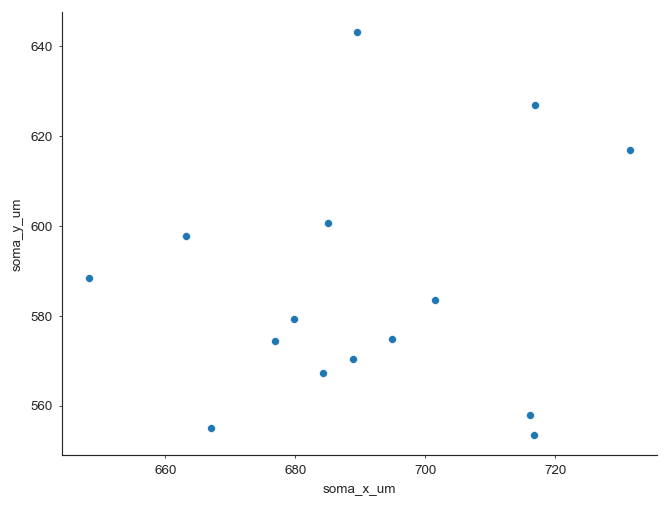

In [36]:
sns.scatterplot(df_website_single, x='soma_x_um', y='soma_y_um');

In [37]:
df_website_single.to_csv(os.path.join(website_dir, f"BC_website_single_examples.csv"))

## Mosaics

In [38]:
# Polygon vertices in order
polygon = np.array([xy0, xy1, xy2, xy3])

def is_in_box(hull_center_x, hull_center_y):
    """
    Returns True if the point is inside the quadrilateral.
    Uses ray casting.
    """
    x, y = hull_center_x, hull_center_y
    inside = False

    n = len(polygon)
    p1x, p1y = polygon[0]

    for i in range(n + 1):
        p2x, p2y = polygon[i % n]

        if min(p1y, p2y) < y <= max(p1y, p2y):
            if x <= max(p1x, p2x):
                if p1y != p2y:
                    xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x

                if p1x == p2x or x <= xinters:
                    inside = not inside

        p1x, p1y = p2x, p2y

    return inside

# Filter dataframe
df_in_box = df[
    df.apply(
        lambda row: is_in_box(row["hull_center_x"], row["hull_center_y"]),
        axis=1
    )
]

df_website_mosaic = df_in_box.loc[df_in_box.valid_celltype_final & df_in_box.celltype_final.isin(plot_order), website_cols].copy()
df_website_mosaic.sort_values('celltype_final', inplace=True)
df_website_mosaic.head()

,celltype_final,soma_x_um,soma_y_um,soma_z_um
cell,,,,
720575940549544148,GluMI,674.859,597.974,35.0765
720575940571967692,GluMI,694.703,617.058,31.7652
720575940556167639,GluMI,728.442,580.559,35.7305
720575940564691700,GluMI,653.195,552.309,30.7186
720575940553631027,GluMI,707.938,544.587,30.3830


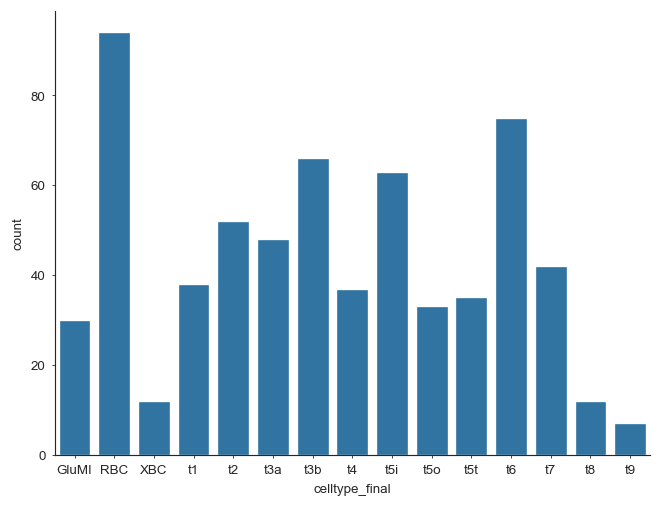

In [39]:
sns.countplot(data=df_website_mosaic, x='celltype_final');

In [40]:
df_website_mosaic.to_csv(os.path.join(website_dir, f"BC_website_mosaic_examples.csv"))